In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ВАХ диода

Измерим ВАХ диода

$R_M$ [Ом]

$U_0$ [В]


$$ U_d = \cfrac{R_M}{R_1 + R_M} U_0, ~R_1 = 910~\textit{Ом}; \ \ \ \ \ I_d = \cfrac{U_0 - U_d}{R_2}, ~R_2 = 9100~\textit{Ом} $$

Погрешность напряжения

$$ \sigma_{U_d} = \sqrt{\left( \cfrac{\partial U_d}{\partial R_M} \right)^2 \sigma^2_{R_M} + \left( \cfrac{\partial U_d}{\partial U_0} \right)^2 \sigma^2_{U_0} + \left( \cfrac{\partial U_d}{\partial R_1} \right)^2 \sigma^2_{R_1} } =  $$

$$ = \sqrt{\left( \cfrac{1}{R_1 + R_M} U_0 - \cfrac{R_M}{\left(R_1 + R_M\right)^2} U_0 \right)^2 \sigma^2_{R_M} + \left( \cfrac{R_M}{R_1 + R_M} \right)^2 \sigma^2_{U_0} + \left( - \cfrac{R_M}{\left(R_1 + R_M\right)^2} U_0 \right)^2 \sigma^2_{R_1} } =  $$

$$ = \cfrac{1}{\left(R_1 + R_M\right)^2} \sqrt{R_1^2 U_0^2 \sigma^2_{R_M} + \left( R_1 + R_M \right)^2 R_M^2 \sigma^2_{U_0} + R_M^2 U_0^2 \sigma^2_{R_1} } $$

Погрешность тока

$$ \sigma_{I_d} = \sqrt{\left( \cfrac{\partial I_d}{\partial U_0} \right)^2 \sigma^2_{U_0} + \left( \cfrac{\partial I_d}{\partial U_d} \right)^2 \sigma^2_{U_d} + \left( \cfrac{\partial I_d}{\partial R_2} \right)^2 \sigma^2_{R_2}} = \sqrt{\left( \cfrac{1}{R_2} \right)^2 \sigma^2_{U_0} + \left( -\cfrac{1}{R_2} \right)^2 \sigma^2_{U_d} + \left( -\cfrac{U_0 - U_d}{R_2^2} \right)^2 \sigma^2_{R_2}} = $$

$$ =  \cfrac{1}{R_2^2}\sqrt{R_2^2 \left( \sigma^2_{U_0} + \sigma^2_{U_d} \right) + \left( U_0 - U_d \right)^2 \sigma^2_{R_2}} $$

In [2]:
D2 = pd.read_csv("D2.csv")
D2

,U_0,scale,sigma_base,R_M
0,0.005,2000,0.25,700.00
1,0.500,20,0.25,233.00
2,1.000,10,0.25,138.00
3,2.000,10,0.25,89.90
4,5.000,2,0.25,51.60
5,7.500,2,0.25,40.30
6,10.000,2,0.25,32.04
7,12.500,1,0.25,26.00
8,15.000,1,0.25,22.60
9,17.500,1,0.25,18.93


In [3]:
R_1 = np.float128('910')
sigma_R_1 = np.float128('0.5')

R_2 = np.float128('9100')
sigma_R_2 = np.float128('0.5')

In [4]:
sigma_R_M = np.float128('0.5')

In [5]:
D2["sigma_U_0"] = D2["sigma_base"] / D2["scale"]

# СИ
D2["U_d"] = D2["R_M"] * D2["U_0"] / (R_1 + D2["R_M"])
D2["sigma_U_d"] = np.sqrt(
    np.square(R_1 * D2["U_0"] * sigma_R_M) + 
    np.square(D2["R_M"] * D2["sigma_U_0"] * (D2["R_M"] + R_1)) + 
    np.square(D2["R_M"] * D2["U_0"] * sigma_R_1)
) / np.square(R_1 + D2["R_M"])

D2["I_d"] = (D2["U_0"] - D2["U_d"]) / R_2
D2["sigma_I_d"] = np.sqrt(
    R_2**2 * (np.square(D2["sigma_U_0"]) + np.square(D2["sigma_U_d"])) + 
    np.square(D2["U_0"] - D2["U_d"]) * sigma_R_2**2
) / R_2**2

# мкА
D2["I_d"] = 1e6 * D2["I_d"]
D2["sigma_I_d"] = 1e6 * D2["sigma_I_d"]

# мВ
D2["U_d"] = 1e3 * D2["U_d"]
D2["sigma_U_d"] = 1e3 * D2["sigma_U_d"]

# D2_tmp = D2.copy()

# D2_ejects = pd.DataFrame(columns=D2_tmp.columns)
# D2 = pd.DataFrame(columns=D2_tmp.columns)

# for i in range(len(D2_tmp["U_0"])):
#     if D2_tmp["U_0"].iloc[i] > 6:
#         D2_ejects.loc[len(D2_ejects)] = D2_tmp.loc[i]
#     else:
#         D2.loc[len(D2)] = D2_tmp.loc[i]

D2

,U_0,scale,sigma_base,R_M,sigma_U_0,U_d,sigma_U_d,I_d,sigma_I_d
0,0.005,2000,0.25,700.00,0.000125,2.173913,0.054359,0.310559,0.014979
1,0.500,20,0.25,233.00,0.012500,101.924759,2.554451,43.744532,1.402017
2,1.000,10,0.25,138.00,0.025000,131.679389,3.318544,95.419847,2.771356
3,2.000,10,0.25,89.90,0.025000,179.817982,2.426682,200.020002,2.760187
4,5.000,2,0.25,51.60,0.125000,268.302829,7.145920,519.966722,13.758721
5,7.500,2,0.25,40.30,0.125000,318.057456,6.512089,789.224455,13.754960
6,10.000,2,0.25,32.04,0.125000,340.112946,6.662909,1061.526050,13.755888
7,12.500,1,0.25,26.00,0.250000,347.222222,9.508105,1335.470085,27.492487
8,15.000,1,0.25,22.60,0.250000,363.499893,9.915598,1608.406605,27.494270
9,17.500,1,0.25,18.93,0.250000,356.619982,10.542202,1883.887914,27.497137


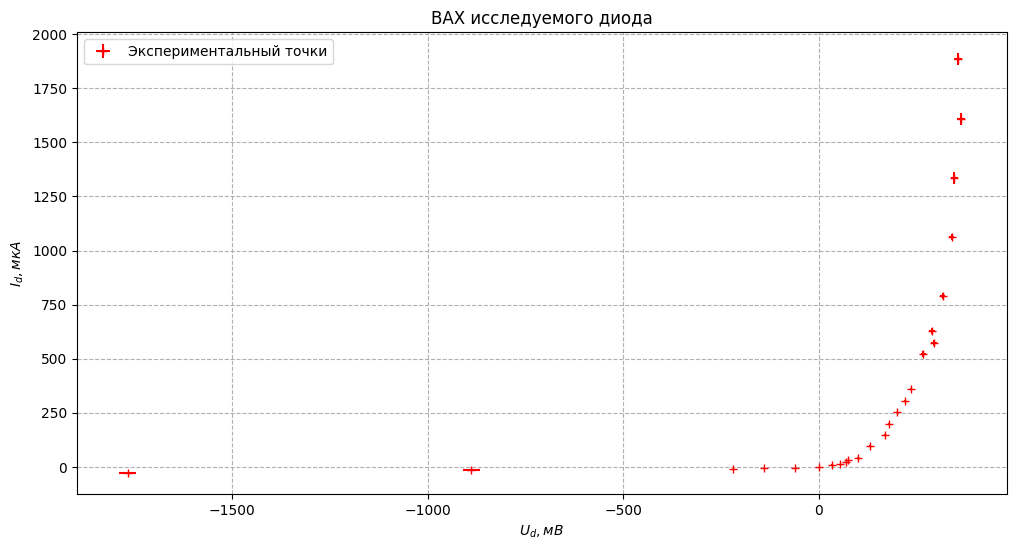

In [6]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title("ВАХ исследуемого диода")


# plt.errorbar(x=D2_ejects["U_d"], xerr=D2_ejects["sigma_U_d"], y=D2_ejects["I_d"], yerr=D2_ejects["sigma_I_d"], fmt="+g", label="Экспериментальный точки")

plt.errorbar(x=D2["U_d"], xerr=D2["sigma_U_d"], y=D2["I_d"], yerr=D2["sigma_I_d"], fmt="+r", label="Экспериментальный точки")



plt.xlabel(r"$U_d, мВ$")
plt.ylabel(r"$I_d, мкА$")


plt.legend()
plt.savefig("pictures/VAH_diode.pdf")
plt.show()

# Калибровка Термопары

In [7]:
# EDS [мкВ]
# T   [C]
thermo_calib = pd.read_csv("thermopair.csv")


Приблизим разными много членами

In [8]:
def polynom(x, *args):
    return np.sum(
        [args[i] * np.power(x, i) for i in range(len(args))]
        , axis=0)

In [9]:
n_s = list(range(2, 5))

approximations = []

for n in n_s:
    x = thermo_calib["EDS"]
    y = thermo_calib["T"]

    popt, pcov = curve_fit(polynom, x, y, p0=tuple((1 for _ in range(n))))

    x_model = np.linspace(0, 5000, 10000)
    y_model = polynom(x_model, *popt)

    approximations.append(
        (n, x_model, y_model, popt, np.sqrt(np.diag(pcov)))
    )


[ 1.64719389e-01  2.55150331e-02 -5.08125035e-07]
[5.45825366e-02 5.37128352e-05 1.10511475e-08]
T = 0.16471938900395056 + 0.025515033084366978*EDS + -5.081250351590683e-07* EDS**2


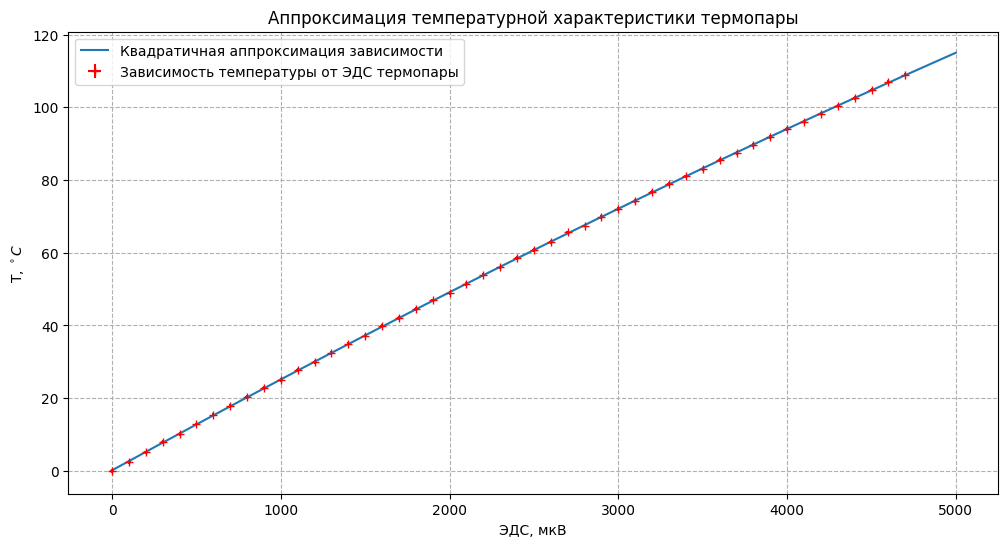

In [10]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title(r"Аппроксимация температурной характеристики термопары")


plt.errorbar(x=thermo_calib["EDS"], xerr=10, y=thermo_calib["T"], yerr=0.5, fmt="+r", label=r"Зависимость температуры от ЭДС термопары")

for n, x_, y_, p, p_err in approximations:
    if n != 3:
        continue

    print(p)
    print(p_err)

    a_0, a_1, a_2 = p
    sigma_a_0, sigma_a_1, sigma_a_2 = p_err

    print(f"T = {a_0} + {a_1}*EDS + {a_2}* EDS**2")

    plt.plot(x_, y_, label=r"Квадратичная аппроксимация зависимости")

plt.xlabel(r"ЭДС, мкВ")
plt.ylabel(r"T, $^\circ C$")

plt.legend()

plt.savefig("pictures/thermopair_approximation.pdf")
plt.show()


Температура от ЭДС

$$ t(\varepsilon) = a_0 + a_1 \varepsilon + a_2 \varepsilon^2 $$

Погрешность

$$ \sigma_t = \sqrt{ \left( \cfrac{\partial t}{\partial a_0} \right)^2 \sigma_{a_0}^2 + \left( \cfrac{\partial t}{\partial a_1} \right)^2 \sigma_{a_1}^2 + \left( \cfrac{\partial t}{\partial a_2} \right)^2 \sigma_{a_2}^2 + \left(\cfrac{\partial t}{\partial \varepsilon} \right)^2 \sigma_\varepsilon^2 } = \sqrt{ \sigma_{a_0}^2 + \varepsilon^2 \sigma_{a_1}^2 + \varepsilon^4 \sigma_{a_2}^2 + \left(a_1 + 2 \varepsilon a_2 \right)^2 \sigma_\varepsilon^2 } $$

In [11]:
print(f"a = {a_0:.2f} +- {sigma_a_0:.2f}")
print(f"b = {a_1:.4f} +- {sigma_a_1:.4f}")
print(f"c = {a_2:.8f} +- {sigma_a_2:.8f}")

a = 0.16 +- 0.05
b = 0.0255 +- 0.0001
c = -0.00000051 +- 0.00000001


In [12]:
def t_from_eds(eds):
    return a_0 + a_1*eds + a_2* eds**2

def sigma_t_from_eds(eds, sigma_eds):
    return np.sqrt(
        np.square(sigma_a_0) + 
        np.square(eds * sigma_a_1) + 
        np.square(eds**2 * sigma_a_2) + 
        np.square(a_1 + 2 * eds * a_2) * np.square(sigma_eds)
    )

# Исследование температурной зависимости

Далее замерим зависимость сопротивления от температуры

$V$ [мВ]

$R_M$ [Ом]


И для обратного тока

$V$ [мВ]

$R_M$ [Ом]


$U_0 = 0.025~\text{В}$

$$ U_d = \cfrac{R_M}{910~\textit{Ом} + R_M} U_0; \ \ \ \ \ I_d = \cfrac{U_0 - U_d}{9100~\textit{Ом}} $$


Погрешность напряжения

$$ \sigma_{U_d} = \sqrt{\left( \cfrac{\partial U_d}{\partial R_M} \right)^2 \sigma^2_{R_M} + \left( \cfrac{\partial U_d}{\partial U_0} \right)^2 \sigma^2_{U_0} + \left( \cfrac{\partial U_d}{\partial R_1} \right)^2 \sigma^2_{R_1} } =  $$

$$ = \sqrt{\left( \cfrac{1}{R_1 + R_M} U_0 - \cfrac{R_M}{\left(R_1 + R_M\right)^2} U_0 \right)^2 \sigma^2_{R_M} + \left( \cfrac{R_M}{R_1 + R_M} \right)^2 \sigma^2_{U_0} + \left( - \cfrac{R_M}{\left(R_1 + R_M\right)^2} U_0 \right)^2 \sigma^2_{R_1} } =  $$

$$ = \cfrac{1}{\left(R_1 + R_M\right)^2} \sqrt{R_1^2 U_0^2 \sigma^2_{R_M} + \left( R_1 + R_M \right)^2 R_M^2 \sigma^2_{U_0} + R_M^2 U_0^2 \sigma^2_{R_1} } $$

Погрешность тока

$$ \sigma_{I_d} = \sqrt{\left( \cfrac{\partial I_d}{\partial U_0} \right)^2 \sigma^2_{U_0} + \left( \cfrac{\partial I_d}{\partial U_d} \right)^2 \sigma^2_{U_d} + \left( \cfrac{\partial I_d}{\partial R_2} \right)^2 \sigma^2_{R_2}} = \sqrt{\left( \cfrac{1}{R_2} \right)^2 \sigma^2_{U_0} + \left( -\cfrac{1}{R_2} \right)^2 \sigma^2_{U_d} + \left( -\cfrac{U_0 - U_d}{R_2^2} \right)^2 \sigma^2_{R_2}} = $$

$$ =  \cfrac{1}{R_2^2}\sqrt{R_2^2 \left( \sigma^2_{U_0} + \sigma^2_{U_d} \right) + \left( U_0 - U_d \right)^2 \sigma^2_{R_2}} $$

$$ R_d = \cfrac{R_2}{R_1} R_M; \ \ \ \ \ \sigma_{R_d} = \cfrac{R_2}{R_1} \sigma_{R_M} $$

In [13]:

# перевод в кельвины
T_0 = np.float128("273.15") # K


# температура сосуда
t_0 = np.float128('24') # C

# нуль вольтметра
V_0 = np.float128('0.10') # mV

# Погрешность V
sigma_V = np.float128('0.01') # mV


## Линейный участок

In [14]:
data = pd.read_csv("data.csv")
data

,R_M,V
0,620.0,0.03
1,540.0,0.12
2,470.0,0.20
3,411.0,0.30
4,358.0,0.40
5,303.0,0.51
6,264.0,0.60
7,230.0,0.70
8,196.0,0.81
9,170.0,0.91


In [15]:
data["V_true"] = data["V"] - V_0

Точные вычисления

In [16]:
data["t"] = t_from_eds(1000 * data["V_true"]) + t_0
data["sigma_t"] = sigma_t_from_eds(1000 * data["V_true"], 1000 * sigma_V)

data["T"] = data["t"] + T_0
data["sigma_T"] = data["sigma_t"]

In [17]:
# Амплитуда для линейног оучастка
A_str = 0.025
sigma_A_str = 0.5 / 2000

# СИ
data["U_d"] = data["R_M"] * 0.025 / (910 + data["R_M"])
data["sigma_U_d"] = np.sqrt(
    np.square(R_1 * A_str * sigma_R_M) + 
    np.square(data["R_M"] * sigma_A_str * (data["R_M"] + R_1)) + 
    np.square(data["R_M"] * A_str * sigma_R_1)
) / np.square(R_1 + data["R_M"])


data["I_d"] = (0.025 - data["U_d"]) / 9100
data["sigma_I_d"] = np.sqrt(
    R_2**2 * (np.square(sigma_A_str) + np.square(data["sigma_U_d"])) + 
    np.square(A_str - data["U_d"]) * sigma_R_2**2
) / R_2**2


data["R_d"] = (R_2 / R_1) * data["R_M"]
data["sigma_R_d"] = (R_2 / R_1) * sigma_R_M

In [18]:
data

,R_M,V,V_true,t,sigma_t,T,sigma_T,U_d,sigma_U_d,I_d,sigma_I_d,R_d,sigma_R_d
0,620.0,0.03,-0.07,22.376177,0.261646,295.526177,0.261646,0.010131,0.000101,0.000002,2.964964e-08,6200.0,5.0
1,540.0,0.12,0.02,24.674817,0.260727,297.824817,0.260727,0.009310,0.000093,0.000002,2.932410e-08,5400.0,5.0
2,470.0,0.20,0.10,26.711141,0.259985,299.861141,0.259985,0.008514,0.000085,0.000002,2.903173e-08,4700.0,5.0
3,411.0,0.30,0.20,29.247401,0.259159,302.397401,0.259159,0.007778,0.000078,0.000002,2.878242e-08,4110.0,5.0
4,358.0,0.40,0.30,31.773498,0.258447,304.923498,0.258447,0.007058,0.000071,0.000002,2.855892e-08,3580.0,5.0
5,303.0,0.51,0.41,34.540467,0.257799,307.690467,0.257799,0.006245,0.000063,0.000002,2.833104e-08,3030.0,5.0
6,264.0,0.60,0.50,36.795205,0.257377,309.945205,0.257377,0.005622,0.000057,0.000002,2.817464e-08,2640.0,5.0
7,230.0,0.70,0.60,39.290814,0.257023,312.440814,0.257023,0.005044,0.000051,0.000002,2.804390e-08,2300.0,5.0
8,196.0,0.81,0.71,42.024247,0.256781,315.174247,0.256781,0.004430,0.000045,0.000002,2.792043e-08,1960.0,5.0
9,170.0,0.91,0.81,44.498515,0.256697,317.648515,0.256697,0.003935,0.000041,0.000002,2.783244e-08,1700.0,5.0


строим зависимость

Погрешность логарифма сопротивления

$$ \sigma_{\ln {R_d}} = \sqrt{\left( \cfrac{\partial \ln{R_d}}{\partial R_d} \right)^2 \sigma_{R_d}^2} = \left| \cfrac{1}{R_d} \right| \sigma_{R_d} = \cfrac{\sigma_{R_d}}{R_d} $$

Погрешность обратной величины

$$ \sigma_{1/T} = \sqrt{\left( \cfrac{\partial (1/T)}{\partial T} \right)^2 \sigma_{T}^2} = \left| - \cfrac{1}{T^2} \right| \sigma_{T} = \cfrac{\sigma_T}{T^2} $$

In [19]:
data["ln_R_d"] = np.log(data["R_d"])
data["sigma_ln_R_d"] = data["sigma_R_d"] / data["R_d"]
# data["sigma_ln_R_d"] = data[""]

data["1/T"] = 1 / data["T"]
data["sigma_1/T"] = data["sigma_T"] / np.square(data["T"])

In [20]:
def linear(x, k, b):
    return k * x + b

k = (5315 +- 34) К
b = (-9.3 +- 0.1)
ln R_d = 5314.618766270709 / T -9.256456735073385


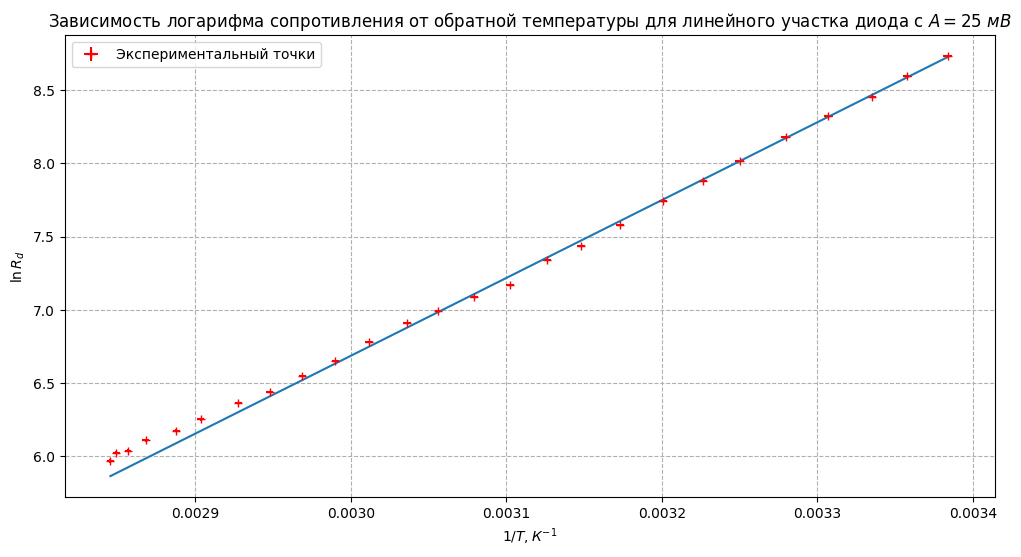

In [21]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title(r"Зависимость логарифма сопротивления от обратной температуры для линейного участка диода с $A = 25~мВ$")



plt.errorbar(y=data["ln_R_d"], yerr=data["sigma_ln_R_d"], x=data["1/T"], xerr=data["sigma_1/T"], fmt="+r", label="Экспериментальный точки")



# Линейная аппроксимация с учетом погрешностей по обеим осям
popt, pcov = curve_fit(linear, xdata=data["1/T"], ydata=data["ln_R_d"], sigma=data["sigma_ln_R_d"])

k_str, b_str = popt
sigma_k_str, sigma_b_str = np.sqrt(np.diag(pcov))

print(f"k = ({k_str:.0f} +- {sigma_k_str:.0f}) К")
print(f"b = ({b_str:.1f} +- {sigma_b_str:.1f})")



print(f"ln R_d = {k_str} / T {b_str}")

x_model = np.linspace(min(data["1/T"]), max(data["1/T"]), 1000)
y_model = linear(x_model, k_str, b_str)


plt.plot(x_model, y_model)

plt.xlabel(r"$1/T, К^{-1}$")
plt.ylabel(r"$\ln {R_d}$")


plt.legend()
plt.savefig("pictures/graph_straight.pdf")
plt.show()

# Для обратного тока

In [22]:
data_reverse = pd.read_csv("data_reverse.csv")
data_reverse

,R_M,V
0,7220.0,0.03
1,2570.0,0.74
2,1304.0,1.04
3,570.0,1.41
4,190.0,1.71
5,78.2,2.05
6,52.0,2.30


In [23]:
data_reverse["V_true"] = data_reverse["V"] - V_0

Точные вычисления

In [24]:
data_reverse["t"] = t_from_eds(1000 * data_reverse["V_true"]) + t_0
data_reverse["sigma_t"] = sigma_t_from_eds(1000 * data_reverse["V_true"], 1000 * sigma_V)

data_reverse["T"] = data_reverse["t"] + T_0
data_reverse["sigma_T"] = data_reverse["sigma_t"]

In [25]:
A_rev = -1
sigma_A_rev = 0.5 / 10

# СИ
data_reverse["U_d"] = data_reverse["R_M"] * A_rev / (R_1 + data_reverse["R_M"])
data_reverse["sigma_U_d"] = np.sqrt(
    np.square(R_1 * A_rev * sigma_R_M) + 
    np.square(data_reverse["R_M"] * sigma_A_rev * (data_reverse["R_M"] + R_1)) + 
    np.square(data_reverse["R_M"] * A_rev * sigma_R_1)
) / np.square(R_1 + data_reverse["R_M"])



data_reverse["I_d"] = (A_rev - data_reverse["U_d"]) / R_2
data_reverse["sigma_I_d"] = np.sqrt(
    R_2**2 * (np.square(sigma_A_rev) + np.square(data_reverse["sigma_U_d"])) + 
    np.square(A_rev - data_reverse["U_d"]) * sigma_R_2**2
) / R_2**2


data_reverse["R_d"] = (R_2 / R_1) * data_reverse["R_M"]
data_reverse["sigma_R_d"] = (R_2 / R_1) * sigma_R_M

# # мВ
# data["U_d"] = 1e3 * data["U_d"]

# # мкА
# data["I_d"] = 1e6 * data["I_d"]

In [26]:
data_reverse

,R_M,V,V_true,t,sigma_t,T,sigma_T,U_d,sigma_U_d,I_d,sigma_I_d,R_d,sigma_R_d
0,7220.0,0.03,-0.07,22.376177,0.261646,295.526177,0.261646,-0.888069,0.044403,-0.000012,0.000007,72200.0,5.0
1,2570.0,0.74,0.64,40.286213,0.256917,313.436213,0.256917,-0.738506,0.036925,-0.000029,0.000007,25700.0,5.0
2,1304.0,1.04,0.94,47.699871,0.256792,320.849871,0.256792,-0.588979,0.029449,-0.000045,0.000006,13040.0,5.0
3,570.0,1.41,1.31,56.717419,0.258409,329.867419,0.258409,-0.385135,0.019258,-0.000068,0.000006,5700.0,5.0
4,190.0,1.71,1.61,63.926812,0.261339,337.076812,0.261339,-0.172727,0.008645,-0.000091,0.000006,1900.0,5.0
5,78.2,2.05,1.95,71.986888,0.266641,345.136888,0.266641,-0.079134,0.003984,-0.000101,0.000006,782.0,5.0
6,52.0,2.30,2.20,77.838467,0.272023,350.988467,0.272023,-0.054054,0.002747,-0.000104,0.000006,520.0,5.0


строим зависимость

In [27]:
data_reverse["ln_|I_d|"] = np.log(np.abs(data_reverse["I_d"]))
data_reverse["sigma_ln_|I_d|"] = data_reverse["sigma_I_d"] / np.abs(data_reverse["I_d"])


data_reverse["1/T"] = 1 / data_reverse["T"]
data_reverse["sigma_1/T"] = data_reverse["sigma_T"] / np.square(data_reverse["T"])

Для оценки по обратному току используем все измеренные точки без ручного исключения.

In [28]:
data_reverse_fit = data_reverse.copy()
data_reverse_fit

,R_M,V,V_true,t,sigma_t,T,sigma_T,U_d,sigma_U_d,I_d,sigma_I_d,R_d,sigma_R_d,ln_|I_d|,sigma_ln_|I_d|,1/T,sigma_1/T
0,7220.0,0.03,-0.07,22.376177,0.261646,295.526177,0.261646,-0.888069,0.044403,-0.000012,0.000007,72200.0,5.0,-11.305901,0.597426,0.003384,0.000003
1,2570.0,0.74,0.64,40.286213,0.256917,313.436213,0.256917,-0.738506,0.036925,-0.000029,0.000007,25700.0,5.0,-10.457373,0.237699,0.003190,0.000003
2,1304.0,1.04,0.94,47.699871,0.256792,320.849871,0.256792,-0.588979,0.029449,-0.000045,0.000006,13040.0,5.0,-10.005141,0.141181,0.003117,0.000002
3,570.0,1.41,1.31,56.717419,0.258409,329.867419,0.258409,-0.385135,0.019258,-0.000068,0.000006,5700.0,5.0,-9.602382,0.087142,0.003032,0.000002
4,190.0,1.71,1.61,63.926812,0.261339,337.076812,0.261339,-0.172727,0.008645,-0.000091,0.000006,1900.0,5.0,-9.305651,0.061336,0.002967,0.000002
5,78.2,2.05,1.95,71.986888,0.266641,345.136888,0.266641,-0.079134,0.003984,-0.000101,0.000006,782.0,5.0,-9.198470,0.054469,0.002897,0.000002
6,52.0,2.30,2.20,77.838467,0.272023,350.988467,0.272023,-0.054054,0.002747,-0.000104,0.000006,520.0,5.0,-9.171600,0.052937,0.002849,0.000002


In [29]:
data_reverse_ejects = pd.DataFrame(columns=data_reverse_fit.columns)
data_reverse = pd.DataFrame(columns=data_reverse_fit.columns)

for i in range(len(data_reverse_fit["1/T"])):
    if data_reverse_fit["1/T"].iloc[i] < 0.0029:
        data_reverse_ejects.loc[len(data_reverse_ejects)] = data_reverse_fit.loc[i]
    else:
        data_reverse.loc[len(data_reverse)] = data_reverse_fit.loc[i]

data_reverse

,R_M,V,V_true,t,sigma_t,T,sigma_T,U_d,sigma_U_d,I_d,sigma_I_d,R_d,sigma_R_d,ln_|I_d|,sigma_ln_|I_d|,1/T,sigma_1/T
0,7220.0,0.03,-0.07,22.376177,0.261646,295.526177,0.261646,-0.888069,0.044403,-0.000012,0.000007,72200.0,5.0,-11.305901,0.597426,0.003384,0.000003
1,2570.0,0.74,0.64,40.286213,0.256917,313.436213,0.256917,-0.738506,0.036925,-0.000029,0.000007,25700.0,5.0,-10.457373,0.237699,0.003190,0.000003
2,1304.0,1.04,0.94,47.699871,0.256792,320.849871,0.256792,-0.588979,0.029449,-0.000045,0.000006,13040.0,5.0,-10.005141,0.141181,0.003117,0.000002
3,570.0,1.41,1.31,56.717419,0.258409,329.867419,0.258409,-0.385135,0.019258,-0.000068,0.000006,5700.0,5.0,-9.602382,0.087142,0.003032,0.000002
4,190.0,1.71,1.61,63.926812,0.261339,337.076812,0.261339,-0.172727,0.008645,-0.000091,0.000006,1900.0,5.0,-9.305651,0.061336,0.002967,0.000002


k = (-4846 +- 152) К
b = (5.1 +- 0.5)


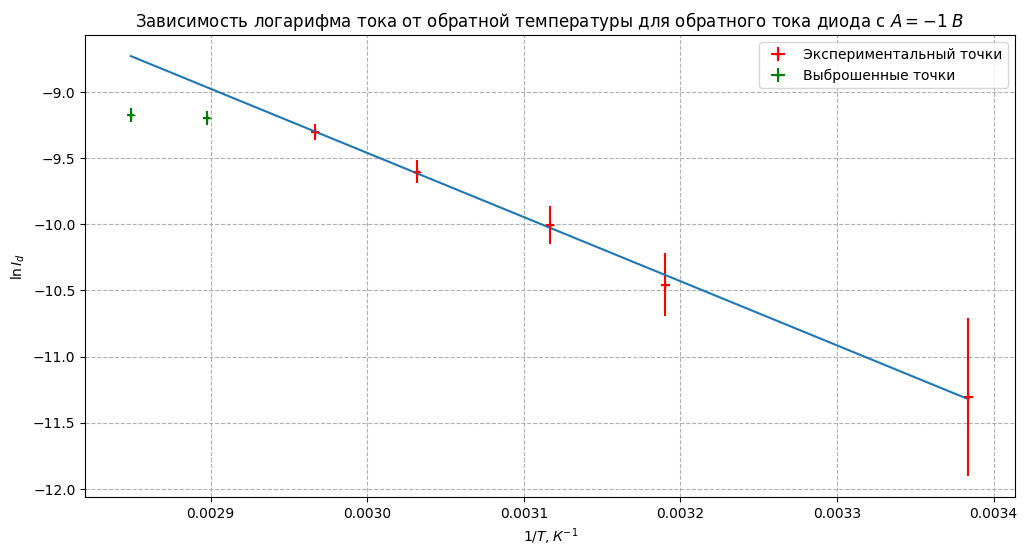

In [30]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title(r"Зависимость логарифма тока от обратной температуры для обратного тока диода с $A = -1~В$")


plt.errorbar(y=data_reverse["ln_|I_d|"], yerr=data_reverse["sigma_ln_|I_d|"], x=data_reverse["1/T"], xerr=data_reverse["sigma_1/T"],
             fmt="+r", label="Экспериментальный точки")

plt.errorbar(y=data_reverse_ejects["ln_|I_d|"], yerr=data_reverse_ejects["sigma_ln_|I_d|"],
             x=data_reverse_ejects["1/T"], xerr=data_reverse_ejects["sigma_1/T"],
             fmt="+g", label="Выброшенные точки")



# Линейная аппроксимация с учетом погрешностей по обеим осям

popt, pcov = curve_fit(linear, xdata=data_reverse["1/T"], ydata=data_reverse["ln_|I_d|"], sigma=data_reverse["sigma_ln_|I_d|"])


k_rev, b_rev = popt
sigma_k_rev, sigma_b_rev = np.sqrt(np.diag(pcov))



print(f"k = ({k_rev:.0f} +- {sigma_k_rev:.0f}) К")
print(f"b = ({b_rev:.1f} +- {sigma_b_rev:.1f})")




x_model = np.linspace(min(data_reverse_fit["1/T"]), max(data_reverse_fit["1/T"]), 1000)
y_model = linear(x_model, k_rev, b_rev)


plt.plot(x_model, y_model)

plt.xlabel(r"$1/T, К^{-1}$")
plt.ylabel(r"$\ln {I_d}$")


plt.legend()
plt.savefig("pictures/graph_reverse.pdf")
plt.show()

# Вычисление КРП

$$ R_d \propto \exp{\left( \cfrac{e \Delta V}{k_\text{Б} T} \right)} \implies \ln{R_d} \propto \cfrac{e \Delta V}{k_\text{Б} T} $$


Тогда


$$ \Delta V = k k_\text{Б} / e $$

In [31]:
# Постоянная больцмана [1e-23 * Дж/К]
k_B = np.float128('1.380649')

# Заряд электрона [1e-19 * Кл]
e = np.float128('1.6')

In [32]:
# По линейному участку
Delta_V = 1e-4 * k_str * k_B / e
sigma_Delta_V = Delta_V * sigma_k_str / k_str

print(f"Delta V = ({Delta_V:.3f} +- {sigma_Delta_V:.3f}) В")

# По обратному току диода
Delta_V_rev = -1e-4 * k_rev * k_B / e
sigma_Delta_V_rev = -Delta_V_rev * sigma_k_rev / k_rev

print(f"Delta V = ({Delta_V_rev:.2f} +- {sigma_Delta_V_rev:.2f}) В")

Delta V = (0.459 +- 0.003) В
Delta V = (0.42 +- 0.01) В
